# E-Commerce Personalization Platform - Data Pipeline Notebook (Refactored)
This refactored notebook performs exploratory_data_analysis.ipynb with modular functions for fetching, inspection, visualization, cleaning, RFM calculations, and splitting. This improves reusability, testing, and maintenance. Functions can be imported/reused in future notebooks.

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import train_test_split

## 1. Data Fetching and Initial Inspection
This section retrieves the UCI Online Retail dataset (ID 352) using the ucimlrepo library, loads the full original DataFrame (including InvoiceNo for RFM), and performs initial check on structure, content, and quality. This helps identify issues like missing values (~25% in CustomerID) and negatives in Quantity/UnitPrice before cleaning

In [20]:
from ucimlrepo import fetch_ucirepo

def fetch_and_inspect_data(identifier: int) -> object:
  """Fetch UCI dataset and perform initial inspection."""
  online_retail = fetch_ucirepo(id=identifier)
  df = online_retail.data.original.copy()

  print(f"Columns in df: {df.columns.tolist()}\n")
  print(f"Shape: {df.shape}\n")
  print(f"First 5 Rows:\n")
  display(df.head())
  print(f"\nData Info:")
  df.info()
  print(f"Summary Statistics:\n{df.describe()}")
  print(f"Missing Values:\n{df.isnull().sum}\n")
  print(f"Date Range (raw): {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

  return df

df = fetch_and_inspect_data(352)


Columns in df: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Shape: (541909, 8)

First 5 Rows:



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
Summary Statistics:
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%     

## 2. Data Visualization
Generate initial plots to explore distributions and patterns in the raw dataset (before cleaning) using Seaborn and Matplotlib. This includes histograms/boxplots for Quantity/UnitPrice (to detect outliers/negatives), top countries/products, and a correlation heatmap; helping guide cleaning decisions.

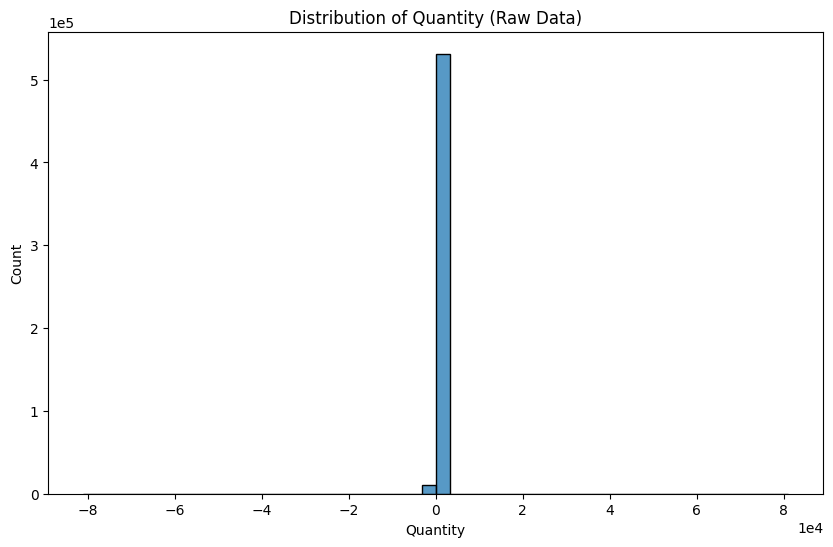

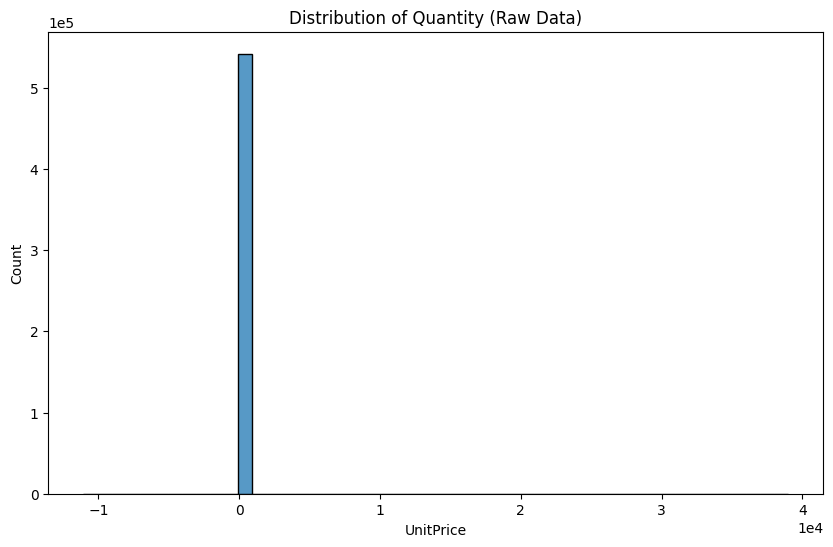

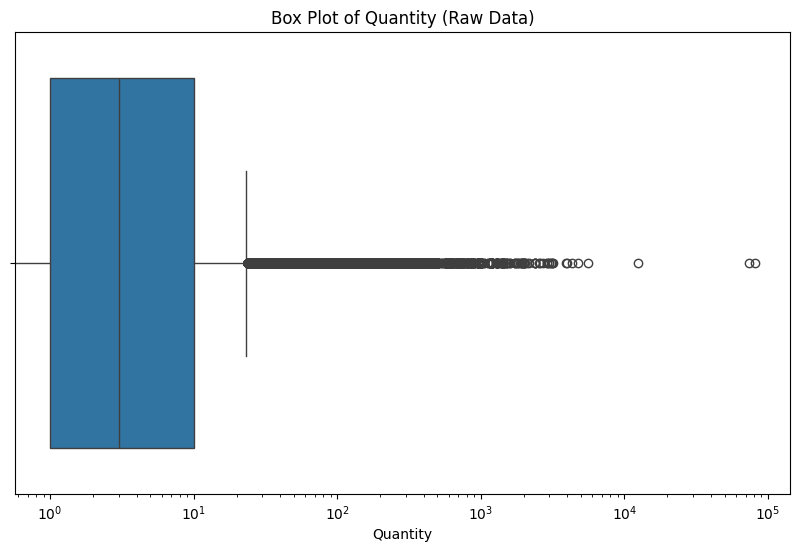

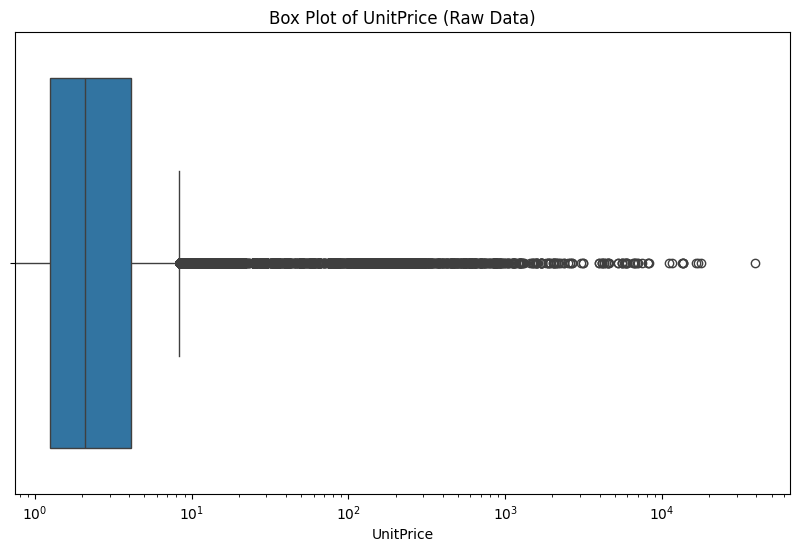

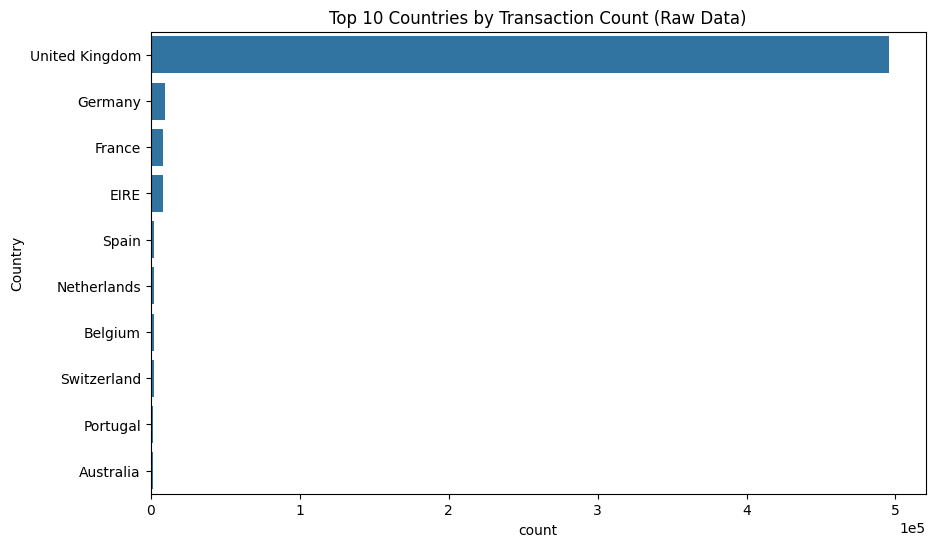

Top 10 Products by Frequency (Raw Data):
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64

Quantity Outliers (min/max): -80995 / 80995
UnitPrice Outliers (min/max): -11062.06 / 38970.0


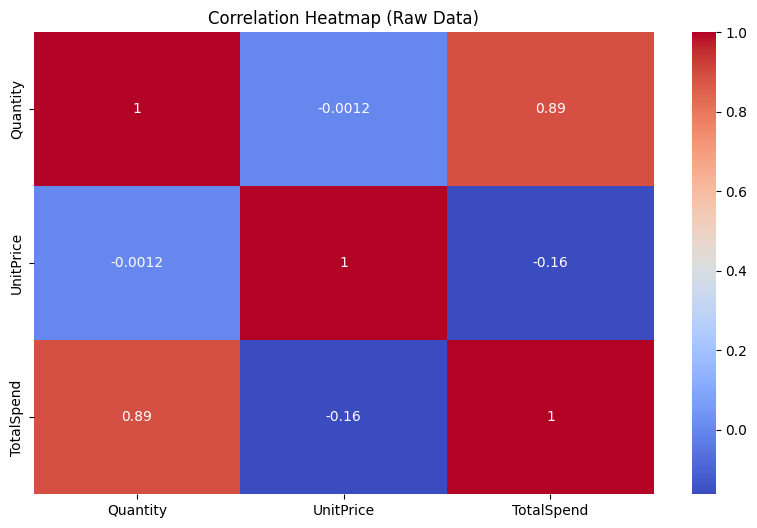

In [19]:
def visualize_raw_data(df: object):
  """Visualize distributions and patterns in raw data."""
  # Quantity distribution
  for col in ['Quantity', 'UnitPrice']:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], bins=50)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.title('Distribution of Quantity (Raw Data)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

  # Boxplots
  for col in ['Quantity', 'UnitPrice']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[col])
    plt.xscale('log')
    plt.title(f'Box Plot of {col} (Raw Data)')
    plt.show()

  # Top 10 countries
  plt.figure(figsize=(10, 6))
  sns.countplot(y='Country', data=df, order=df['Country'].value_counts().index[:10])
  plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
  plt.title('Top 10 Countries by Transaction Count (Raw Data)')
  plt.show()

  # Top 10 products
  print("Top 10 Products by Frequency (Raw Data):")
  print(df['Description'].value_counts().head(10))

  # Outlier min/max
  print(f"\nQuantity Outliers (min/max): {df['Quantity'].min()} / {df['Quantity'].max()}")
  print(f"UnitPrice Outliers (min/max): {df['UnitPrice'].min()} / {df['UnitPrice'].max()}")

  # Correlation heatmap (temp TotalSpend)
  df_temp = df.copy()
  df_temp['TotalSpend'] = df_temp['Quantity'] * df_temp['UnitPrice']
  plt.figure(figsize=(10, 6))
  sns.heatmap(df_temp[['Quantity', 'UnitPrice', 'TotalSpend']].corr(), annot=True, cmap='coolwarm')
  plt.title('Correlation Heatmap (Raw Data)')
  plt.show()

visualize_raw_data(df)

## 3. Data Cleaning and Preprocessing
Perform data cleaning: remove cancellations (Quantity <=0), drop rows with missing CustomerID (~25%), filter negative UnitPrice, convert InvoiceData to datetime, and calculate TotalSpend. Verify changes with stats and save as 'data/cleaned_online_retail.csv' for further analysis

In [17]:
def clean_data(df):
    """Clean the data and verify changes."""
    df_clean = df[df['Quantity'] > 0].copy()
    df_clean = df_clean.dropna(subset=['CustomerID'])
    df_clean = df_clean[df_clean['UnitPrice'] >= 0]
    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='%m/%d/%Y %H:%M', errors='coerce')
    df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

    # Verify
    print(f"Shape after cleaning: {df_clean.shape}")
    print(f"Missing Values after cleaning:\n{df_clean.isnull().sum()}")
    print(f"Quantity min/max after cleaning: {df_clean['Quantity'].min()} / {df_clean['Quantity'].max()}")
    print(f"UnitPrice min/max after cleaning: {df_clean['UnitPrice'].min()} / {df_clean['UnitPrice'].max()}")
    print(f"TotalSpend min/max after cleaning: {df_clean['TotalSpend'].min()} / {df_clean['TotalSpend'].max()}")
    print(f"Date Range after cleaning: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")

    return df_clean

df_clean = clean_data(df)

# Save cleaned data
df_clean.to_csv('data/cleaned_online_retail.csv', index=False)
print("Data saved locally as 'data/cleaned_online_retail.csv'")

Shape after cleaning: (397924, 9)
Missing Values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalSpend     0
dtype: int64
Quantity min/max after cleaning: 1 / 80995
UnitPrice min/max after cleaning: 0.0 / 8142.75
TotalSpend min/max after cleaning: 0.0 / 168469.6
Date Range after cleaning: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Data saved locally as 'data/cleaned_online_retail.csv'


## 4. RFM Features Calculation and Post-Cleaning Verification
Calculate RFM (Recency: days since last purchase; Frequency: unique transactions; Monetary: total spend) for customer segmentation. Perform post-cleaning EDA with log-scaled plots to verify (no negatives, reduced outliers). Save RFM as 'data/rfm_features.csv'.

RFM DataFrame:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40

RFM Summary Statistics:
         CustomerID      Recency    Frequency       Monetary
count   4339.000000  4339.000000  4339.000000    4339.000000
mean   15299.936852    92.518322     4.271952    2053.793018
std     1721.889758   100.009747     7.705493    8988.248381
min    12346.000000     1.000000     1.000000       0.000000
25%    13812.500000    18.000000     1.000000     307.245000
50%    15299.000000    51.000000     2.000000     674.450000
75%    16778.500000   142.000000     5.000000    1661.640000
max    18287.000000   374.000000   210.000000  280206.020000


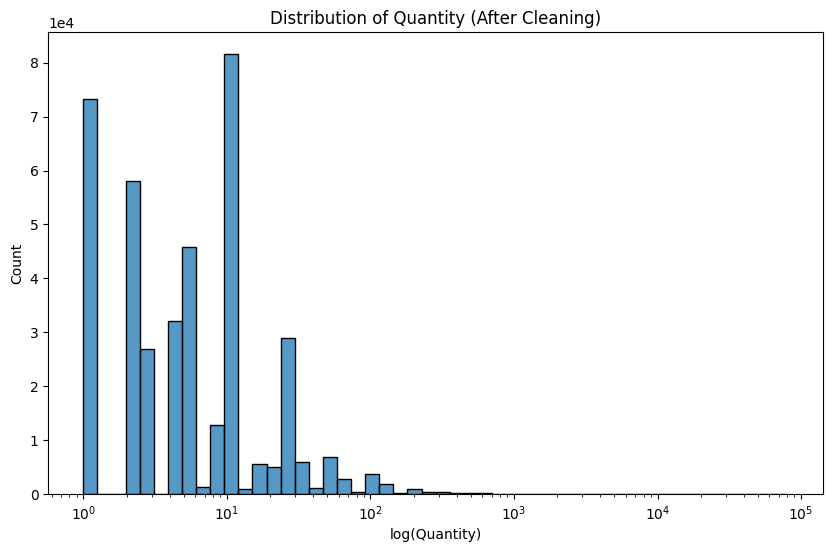

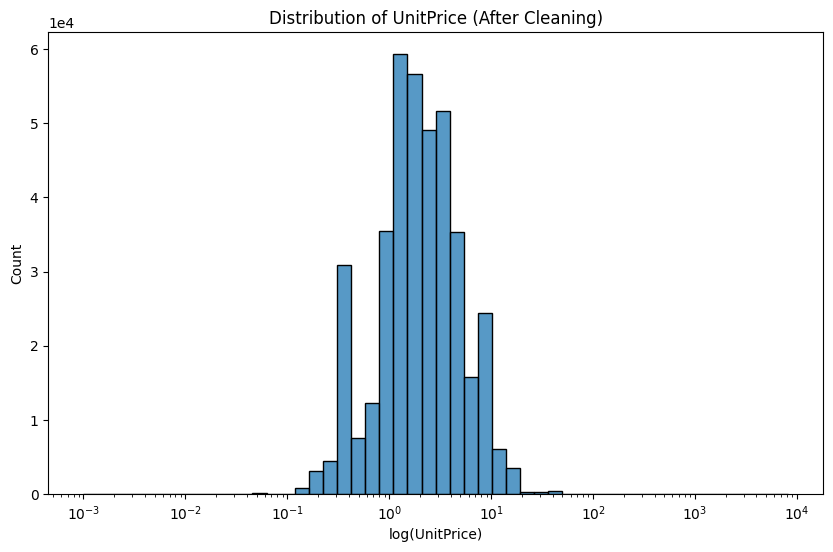

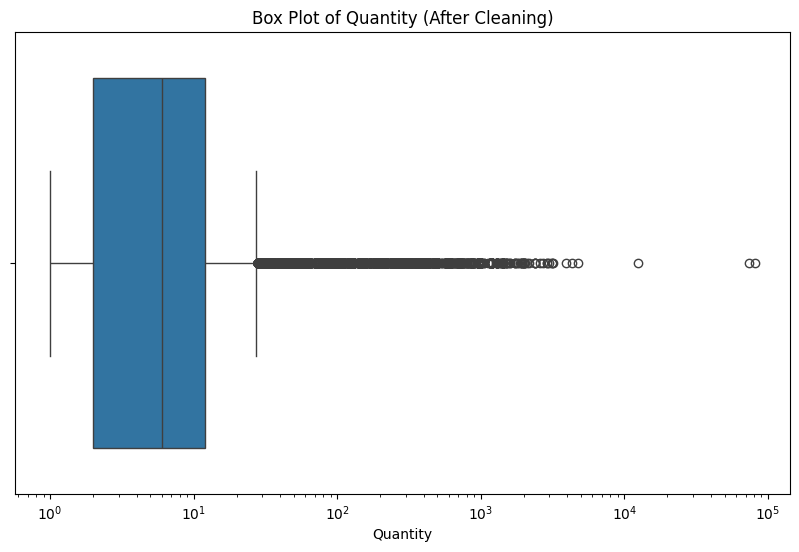

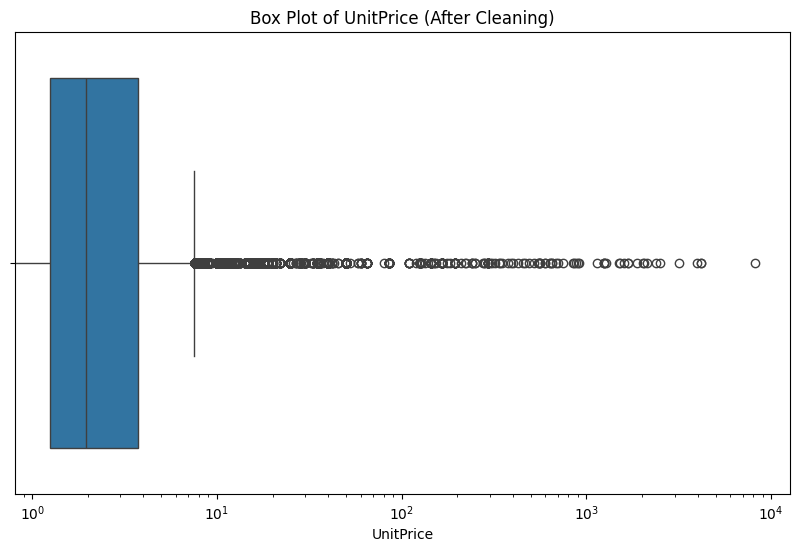

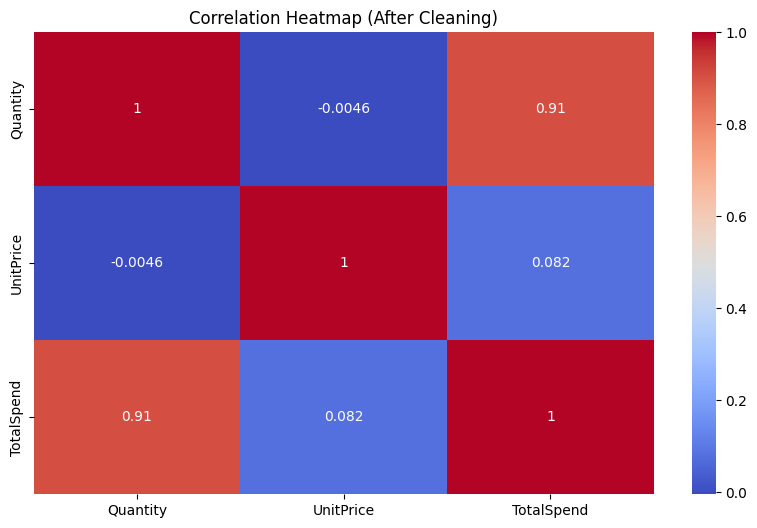

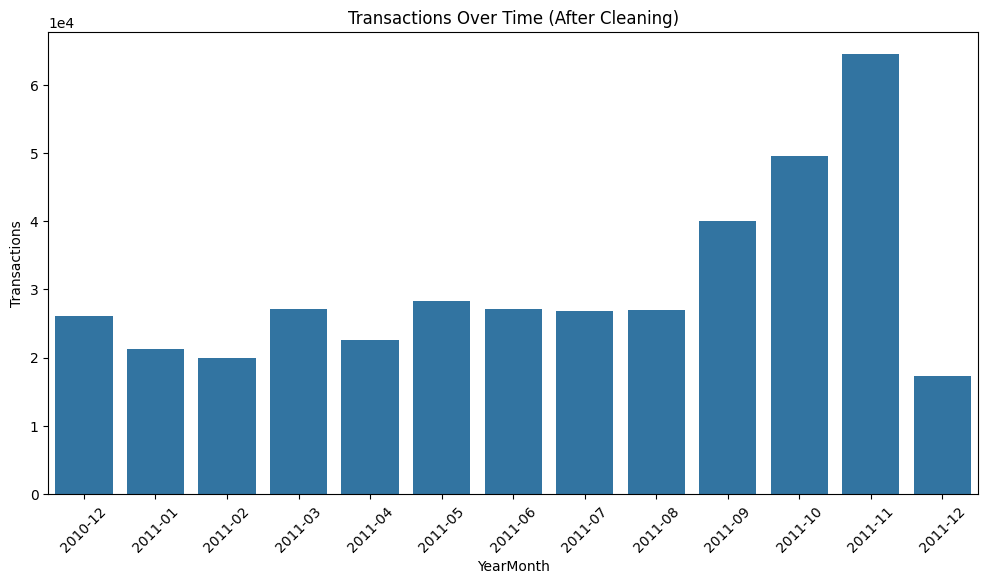

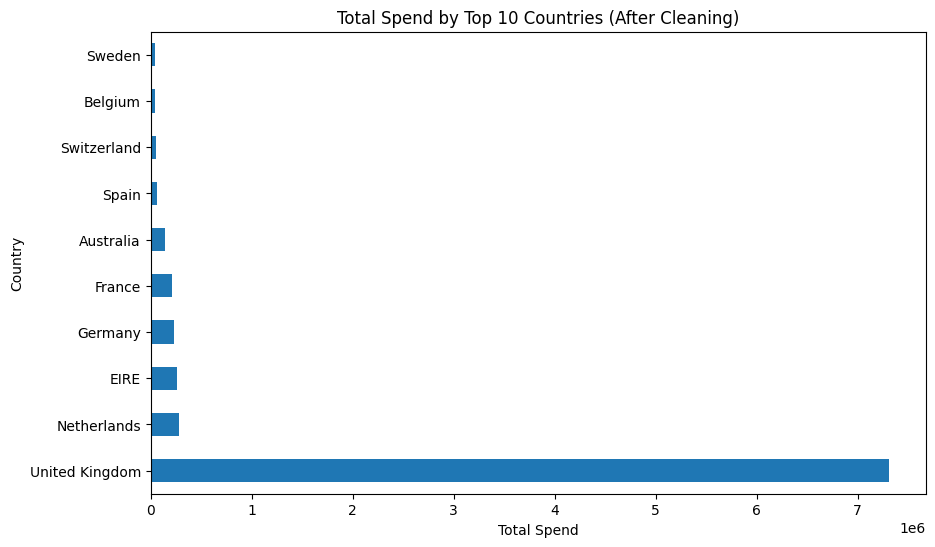

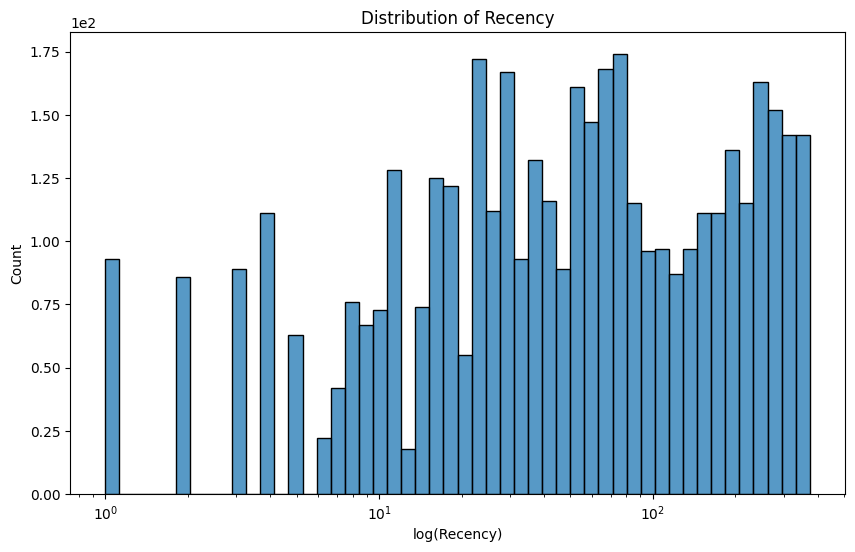

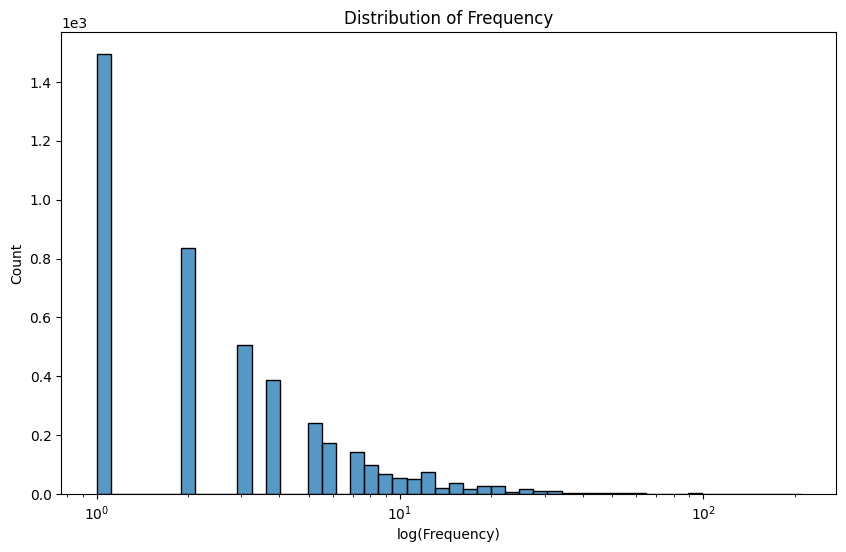

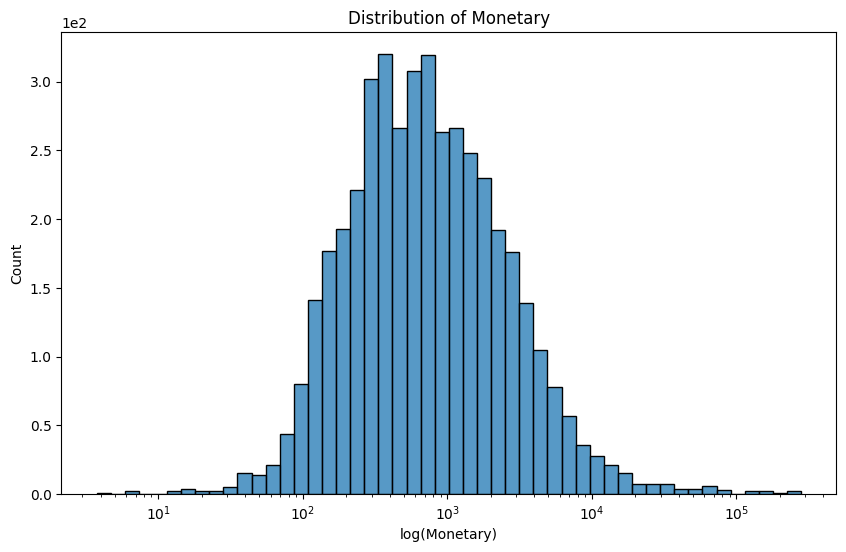

RFM features saved as 'data/rfm_features.csv'


In [24]:
def compute_rfm(df_clean):
    """Calculate RFM features."""
    today = df_clean['InvoiceDate'].max() + datetime.timedelta(days=1)
    rfm = df_clean.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (today - x.max()).days,
        'InvoiceNo': 'nunique',
        'TotalSpend': 'sum'
    }).reset_index()
    rfm = rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalSpend': 'Monetary'})
    return rfm

rfm = compute_rfm(df_clean)

# Verify
print("RFM DataFrame:")
print(rfm.head())
print("\nRFM Summary Statistics:")
print(rfm.describe())

def visualize_post_clean(df_clean, rfm):
    """Post-cleaning visualizations with log scales."""
    # Histograms and boxplots
    for col in ['Quantity', 'UnitPrice']:
        plt.figure(figsize=(10, 6))
        sns.histplot(df_clean[col], bins=50, log_scale=True)
        plt.title(f'Distribution of {col} (After Cleaning)')
        plt.xlabel(f'log({col})')
        plt.ylabel('Count')
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        plt.show()

    for col in ['Quantity', 'UnitPrice']:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df_clean[col])
        plt.title(f'Box Plot of {col} (After Cleaning)')
        plt.xscale('log')
        plt.show()

    # Correlation heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_clean[['Quantity', 'UnitPrice', 'TotalSpend']].corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap (After Cleaning)')
    plt.show()

    # Transactions over time
    df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
    plt.figure(figsize=(12, 6))
    sns.countplot(x='YearMonth', data=df_clean)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.title('Transactions Over Time (After Cleaning)')
    plt.xticks(rotation=45)
    plt.ylabel('Transactions')
    plt.show()

    # Total Spend by Top 10 Countries
    country_spend = df_clean.groupby('Country')['TotalSpend'].sum().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    country_spend.plot(kind='barh')
    plt.title('Total Spend by Top 10 Countries (After Cleaning)')
    plt.xlabel('Total Spend')
    plt.ylabel('Country')
    plt.show()

    # RFM distributions
    for col in ['Recency', 'Frequency', 'Monetary']:
        plt.figure(figsize=(10, 6))
        sns.histplot(rfm[col], bins=50, log_scale=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(f'log({col})')
        plt.ylabel('Count')
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        plt.show()

visualize_post_clean(df_clean, rfm)

# Save RFM
rfm.to_csv('data/rfm_features.csv', index=False)
print("RFM features saved as 'data/rfm_features.csv'")

## 5. Data Splitting
Split the cleaned dataset and RFM into train (70%), validation (15%), and test (15%) sets. This prepares for modeling (e.g., val for hyperparameter tuning, test for unbiased evaluation). Saves as CSVs in 'data/' for later days.

In [25]:
def split_data(df, test_size=0.15, val_size=0.1765, random_state=42):
  """Split data into train/val/test (approx 70/15/15)."""
  train_val, test = train_test_split(df, test_size=test_size, random_state=random_state)
  train, val = train_test_split(train_val, test_size=val_size, random_state=random_state)
  return train, val, test

train, val, test = split_data(df_clean)

print(f"Train shape: {train.shape}")
print(f"Validation shape: {val.shape}")
print(f"Test shape: {test.shape}")

train_rfm, val_rfm, test_rfm = split_data(rfm)

print(f"RFM Train shape: {train_rfm.shape}")
print(f"RFM Validation shape: {val_rfm.shape}")
print(f"RFM Test shape: {test_rfm.shape}")

# Save
train.to_csv('data/train.csv', index=False)
val.to_csv('data/val.csv', index=False)
test.to_csv('data/test.csv', index=False)
train_rfm.to_csv('data/rfm_train.csv', index=False)
val_rfm.to_csv('data/rfm_val.csv', index=False)
test_rfm.to_csv('data/rfm_test.csv', index=False)
print("Train, val, test, and RFM splits saved to 'data/' folder")

Train shape: (278536, 10)
Validation shape: (59699, 10)
Test shape: (59689, 10)
RFM Train shape: (3037, 4)
RFM Validation shape: (651, 4)
RFM Test shape: (651, 4)
Train, val, test, and RFM splits saved to 'data/' folder


## 7. Unit Tests with pytest
Add simple unit tests to verify key functions (e.g., cleaning reduces rows, RFM has 3 columns, splits sum to original). Save as 'tests/test_pipeline.py' and run pytest tests/ in terminal.

In [ ]:
# Example in notebook; save as tests/test_pipeline.py for pytest
def test_clean_data(df):
    df_clean = clean_data(df)
    assert df_clean.shape[0] < df.shape[0], "Cleaning should reduce rows"
    assert df_clean['Quantity'].min() > 0, "No negative Quantity after cleaning"
    assert 'TotalSpend' in df_clean.columns, "TotalSpend column missing"

def test_compute_rfm(df_clean):
    rfm = compute_rfm(df_clean)
    assert rfm.shape[1] == 4, "RFM should have 4 columns (incl CustomerID)"
    assert all(col in rfm.columns for col in ['Recency', 'Frequency', 'Monetary']), "Missing RFM columns"
    assert rfm['Recency'].min() >= 0, "Recency should be non-negative"

def test_split_data(df_clean):
    train, val, test = split_data(df_clean)
    assert len(train) + len(val) + len(test) == len(df_clean), "Splits should sum to original size"
    assert abs(len(val) / len(df_clean) - 0.15) < 0.01, "Val size approx 15%"

# Run manually in notebook (for demo; use pytest in terminal)
test_clean_data(df)  # Use small df sample if large
test_compute_rfm(df_clean)
test_split_data(df_clean)
print("Manual tests passed; run pytest for full verification.")